<a href="https://colab.research.google.com/github/icosahedron31/Facial-Expression-Recognition/blob/main/CNNMLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install kaggle wandb onnx -Uq


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
! mkdir ~/.kaggle

In [ ]:
!cp /content/drive/MyDrive/ColabNotebooks/kaggle_API_credentials/kaggle.json ~/.kaggle/kaggle.json

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge

100% 285M/285M [00:07<00:00, 39.3MB/s]



In [ ]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


In [27]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tdola23 (tdola23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

**Imports**

In [14]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory
from sklearn.model_selection import train_test_split
device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cpu


**Reading Data**

In [40]:
df = pd.read_csv('../content/train.csv')
df.head()

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


**Train Test Split**

In [51]:
train_ds, test_ds = train_test_split(df, test_size = 0.3, random_state=42)
test_ds, val_ds = train_test_split(test_ds, test_size = 0.5, random_state=42)
train_ds.head(), val_ds.head()

(       emotion                                             pixels
 14421        0  157 154 157 137 94 99 115 104 120 110 128 98 1...
 9226         4  11 13 17 20 20 21 24 29 28 28 30 33 40 50 57 6...
 994          2  242 250 154 76 80 69 57 53 50 59 55 45 46 49 5...
 28675        0  111 111 112 110 111 111 109 106 99 88 44 68 12...
 4600         3  7 1 4 17 9 11 25 30 33 31 23 38 29 42 56 48 60...,
        emotion                                             pixels
 17147        3  136 136 137 136 138 137 137 135 133 102 52 36 ...
 14040        3  45 26 33 65 47 36 37 35 36 66 88 69 53 38 47 3...
 21306        3  80 78 78 77 76 76 80 115 132 111 93 80 86 92 8...
 22365        3  250 250 250 251 251 251 252 159 58 69 50 44 42...
 22196        1  255 255 255 255 253 255 165 85 62 57 63 72 90 ...)

**Transform**

In [43]:
st = train_ds.iloc[0]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((48, 48)),
    transforms.Normalize([0.5], [0.5])
])
pixels = st["pixels"]
pixels = np.fromstring(pixels, dtype=np.uint8, sep=" ").reshape(48, 48)
pixels = transform(pixels)
pixels

tensor([[[ 0.2314,  0.2078,  0.2314,  ..., -0.5922, -0.7255, -0.3804],
         [ 0.2471,  0.2314,  0.2157,  ..., -0.5686, -0.6941, -0.5686],
         [ 0.2549,  0.2627,  0.1216,  ..., -0.5922, -0.6314, -0.6941],
         ...,
         [ 0.8039,  0.7412,  0.5059,  ...,  0.4902,  0.4039,  0.2078],
         [ 0.7961,  0.6706,  0.3647,  ...,  0.5059,  0.4588,  0.3020],
         [ 0.7490,  0.5686,  0.2471,  ...,  0.5294,  0.4667,  0.4039]]])

**Creating Dataset**

In [49]:
class CustomImageDataset(Dataset):
  def __init__(self, df, transform=None) :
    self.df = df
    self.transform = transform
  def __getitem__(self, index) :
    rows = self.df.iloc[index]
    pixels = rows["pixels"]
    label = torch.tensor(rows["emotion"], dtype=torch.long).to(device)
    pixels = np.fromstring(pixels, dtype=np.uint8, sep=" ").reshape(48, 48)
    pixels = self.transform(pixels)
    return pixels, label
  def __len__(self) :
    return len(self.df)

In [52]:
train_ds = CustomImageDataset(train_ds, transform)
val_ds = CustomImageDataset(val_ds, transform)

**Models**

In [46]:
import torch
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(20 * 20 * 20, 128)
        self.fc2 = nn.Linear(128, 7)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

**Train Loop**

In [58]:
import copy
def train_loop(train_ds, val_ds, model_name, learning_rate, batch_size, model) :
  EPOCHS = 30
  train_dataloader = DataLoader(train_ds, batch_size, shuffle=True)
  val_dataloader = DataLoader(val_ds, batch_size, shuffle=True)
  criterion = nn.CrossEntropyLoss()
  best_model = model
  best_acc_val = 0
  optimizer = Adam(model.parameters(), lr = learning_rate)
  for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_loss_val = 0
    total_acc_val = 0

    for inputs, labels in train_dataloader:
      optimizer.zero_grad()
      outputs = model(inputs)
      train_loss = criterion(outputs, labels)
      total_loss_train += train_loss.item()
      train_loss.backward()

      train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_train += train_acc
      optimizer.step()

    with torch.no_grad():
      for inputs, labels in val_dataloader:
        outputs = model(inputs)
        val_loss = criterion(outputs, labels)
        total_loss_val += val_loss.item()

        val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
        total_acc_val += val_acc
    if total_acc_val > best_acc_val :
        best_acc_val = total_acc_val
        best_model = copy.deepcopy(model.state_dict())

    print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_ds.__len__() * 100, 4)}
                Validation Loss: {round(total_loss_val/100, 4)} Validation Accuracy: {round((total_acc_val)/val_ds.__len__() * 100, 4)}''')
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

    wandb.log({
        "epoch": epoch,
        "train_loss": total_loss_train,
        "train_acc": total_acc_train,
        "val_loss": total_loss_val,
        "val_acc": total_acc_val
    })

  return best_model

**Overfitting Small Dataset**

Epoch 1/30, Train Loss: 0.2485 Train Accuracy 12.0
                Validation Loss: 0.241 Validation Accuracy: 30.0
Epoch 2/30, Train Loss: 0.238 Train Accuracy 27.0
                Validation Loss: 0.2299 Validation Accuracy: 28.0
Epoch 3/30, Train Loss: 0.2276 Train Accuracy 28.0
                Validation Loss: 0.2239 Validation Accuracy: 28.0
Epoch 4/30, Train Loss: 0.2208 Train Accuracy 27.0
                Validation Loss: 0.2148 Validation Accuracy: 28.0
Epoch 5/30, Train Loss: 0.2139 Train Accuracy 29.0
                Validation Loss: 0.2062 Validation Accuracy: 30.0
Epoch 6/30, Train Loss: 0.208 Train Accuracy 34.0
                Validation Loss: 0.1981 Validation Accuracy: 36.0
Epoch 7/30, Train Loss: 0.1981 Train Accuracy 35.0
                Validation Loss: 0.1896 Validation Accuracy: 48.0
Epoch 8/30, Train Loss: 0.1874 Train Accuracy 50.0
                Validation Loss: 0.1786 Validation Accuracy: 53.0
Epoch 9/30, Train Loss: 0.1795 Train Accuracy 51.0
                

/tmp/ipykernel_3170/2878414425.py:41: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))


Epoch 22/30, Train Loss: 0.0598 Train Accuracy 91.0
                Validation Loss: 0.0532 Validation Accuracy: 94.0
Epoch 23/30, Train Loss: 0.0569 Train Accuracy 90.0
                Validation Loss: 0.054 Validation Accuracy: 90.0
Epoch 24/30, Train Loss: 0.0515 Train Accuracy 94.0
                Validation Loss: 0.0438 Validation Accuracy: 94.0
Epoch 25/30, Train Loss: 0.0446 Train Accuracy 93.0
                Validation Loss: 0.0425 Validation Accuracy: 94.0
Epoch 26/30, Train Loss: 0.0435 Train Accuracy 96.0
                Validation Loss: 0.0362 Validation Accuracy: 97.0
Epoch 27/30, Train Loss: 0.0396 Train Accuracy 96.0
                Validation Loss: 0.0304 Validation Accuracy: 99.0
Epoch 28/30, Train Loss: 0.0345 Train Accuracy 95.0
                Validation Loss: 0.0275 Validation Accuracy: 100.0
Epoch 29/30, Train Loss: 0.0291 Train Accuracy 100.0
                Validation Loss: 0.0299 Validation Accuracy: 97.0
Epoch 30/30, Train Loss: 0.0288 Train Accuracy 96.0
   

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▂▂▂▂▃▃▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇█▇█████
train_loss,██▇▇▇▇▆▆▆▆▅▅▄▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▁▁▁▁▂▃▃▃▅▄▅▆▆▆▆▆▇▇▇█▇▇▇▇█████
val_loss,██▇▇▇▇▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
epoch,29
train_acc,96
train_loss,2.88072
val_acc,100
val_loss,2.31529


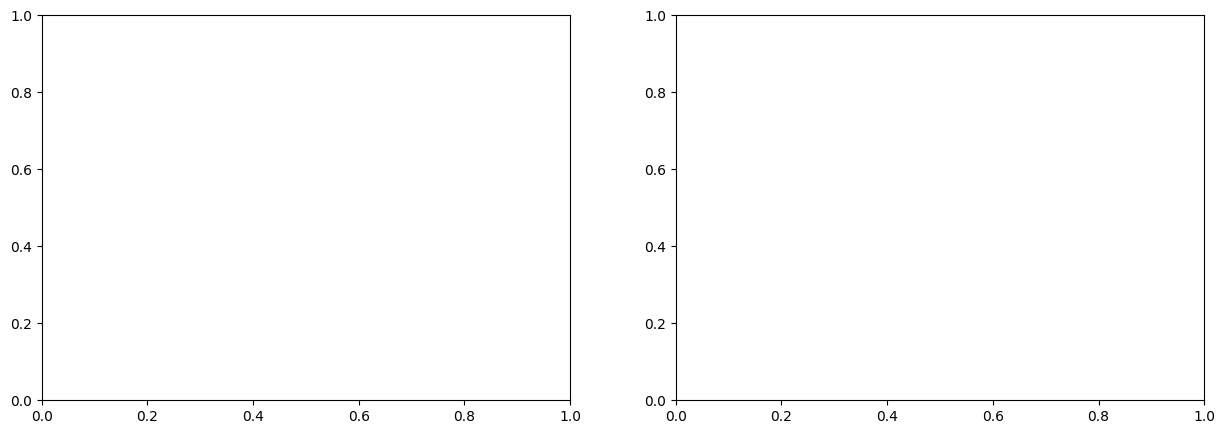

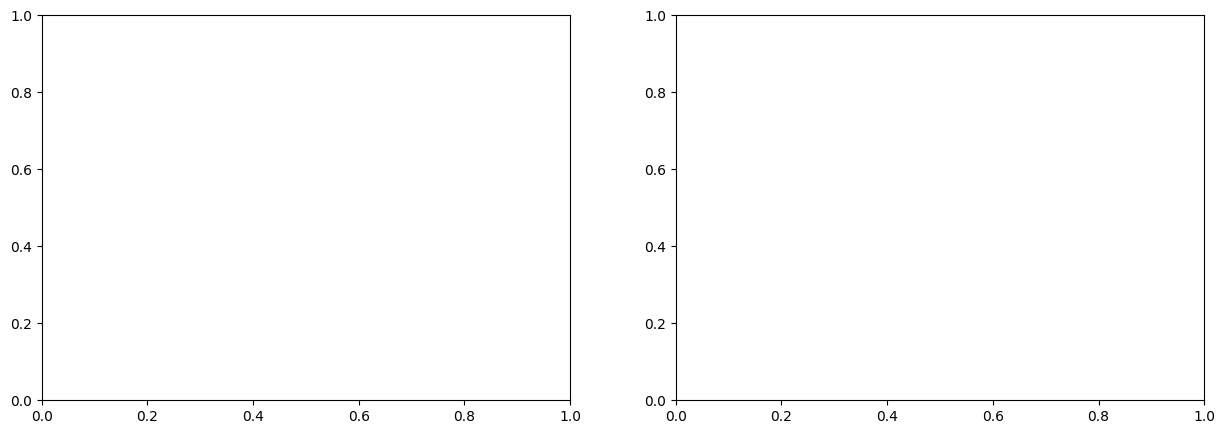

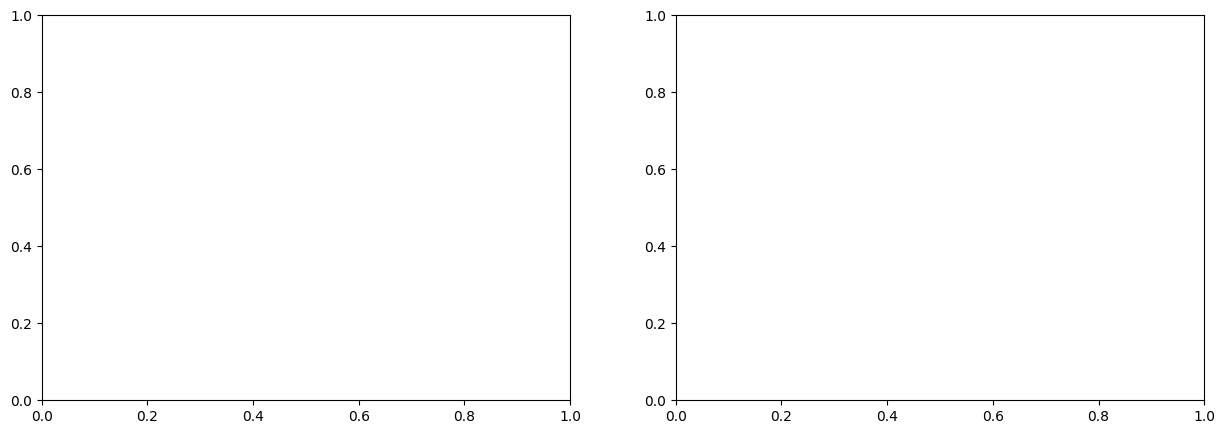

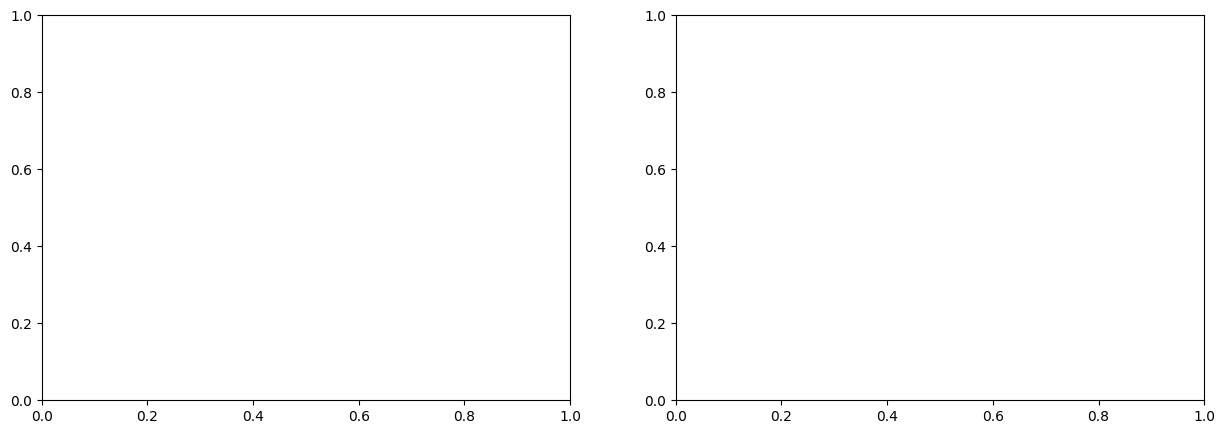

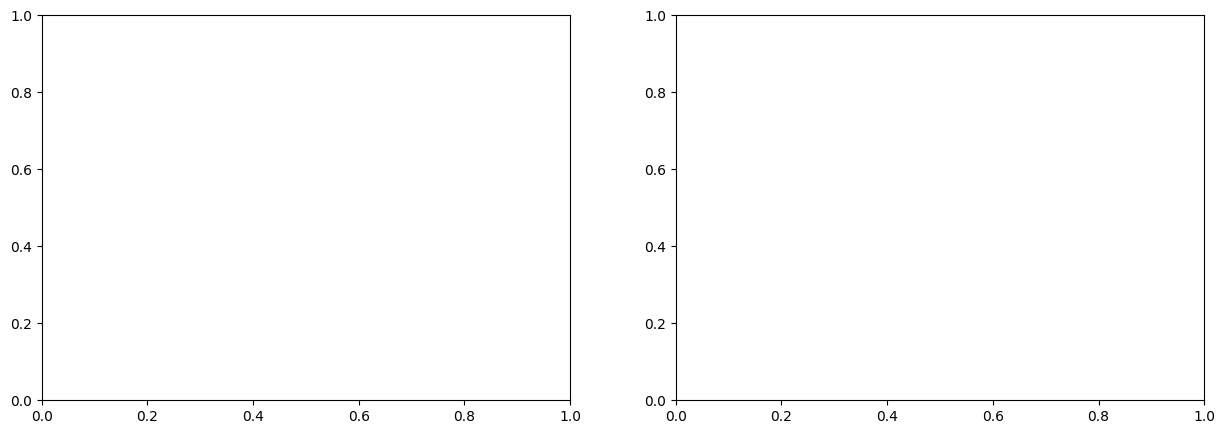

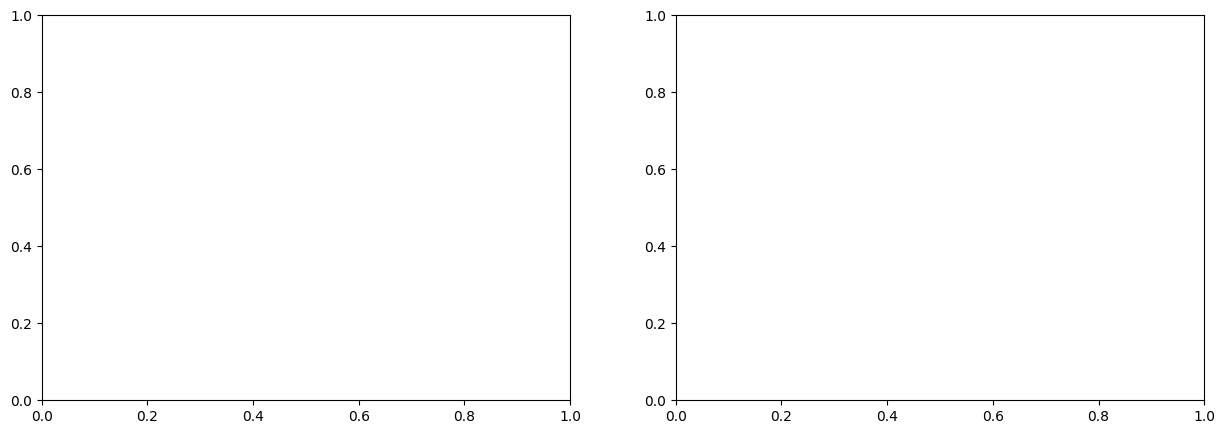

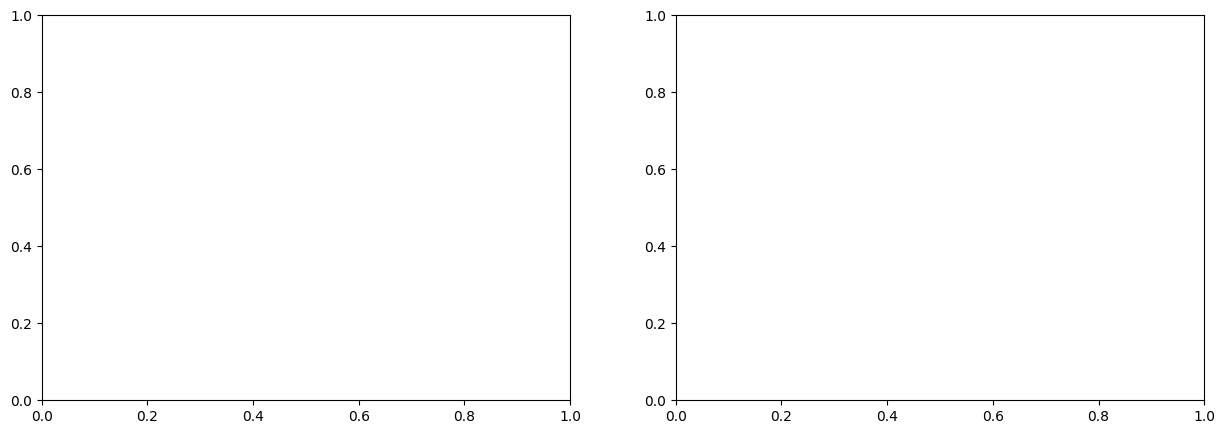

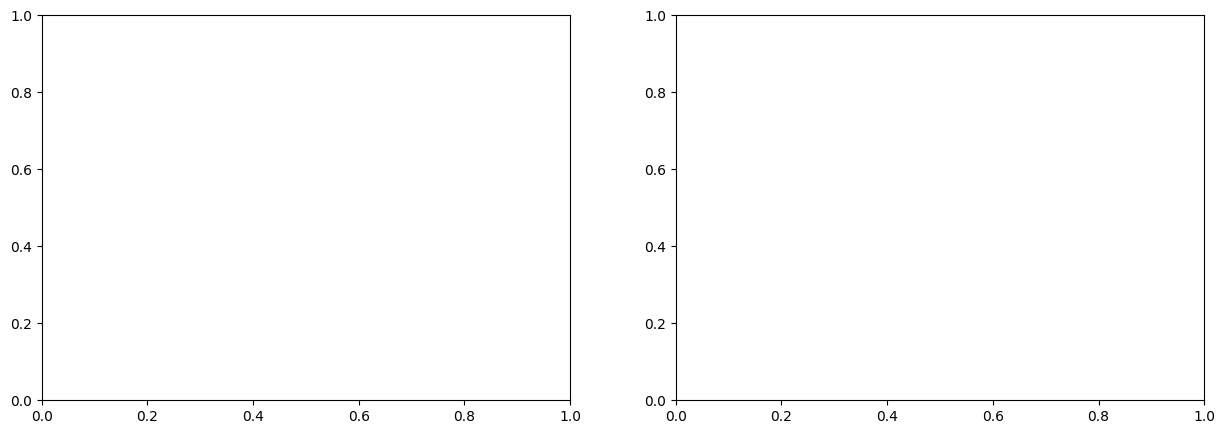

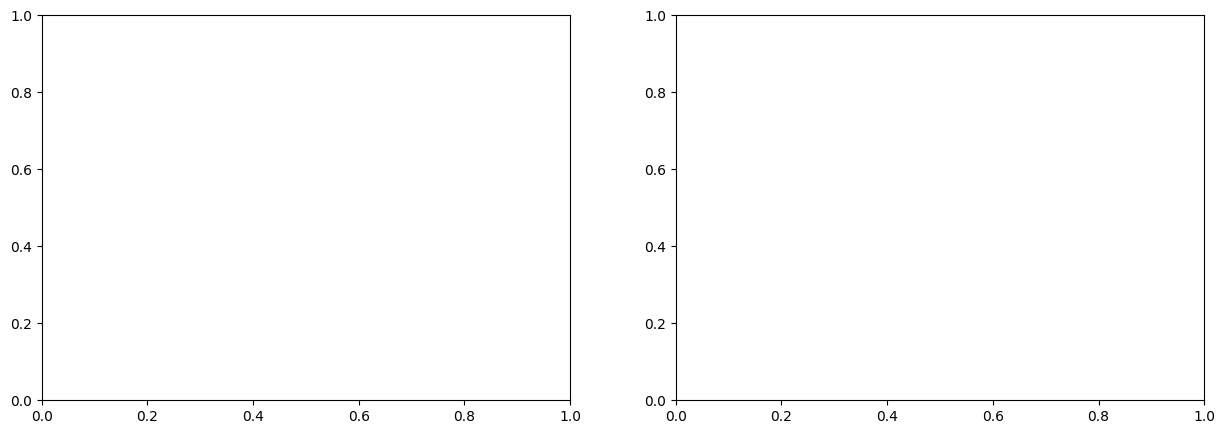

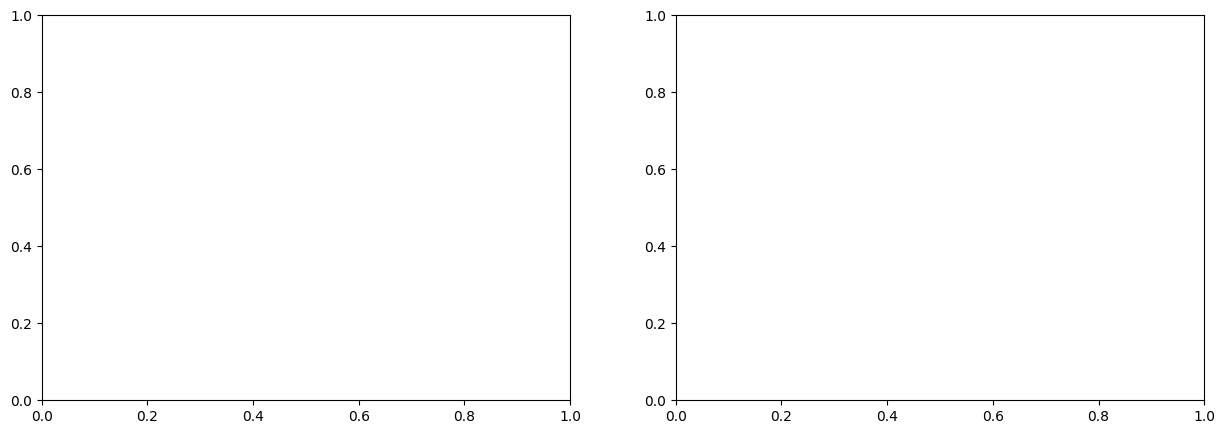

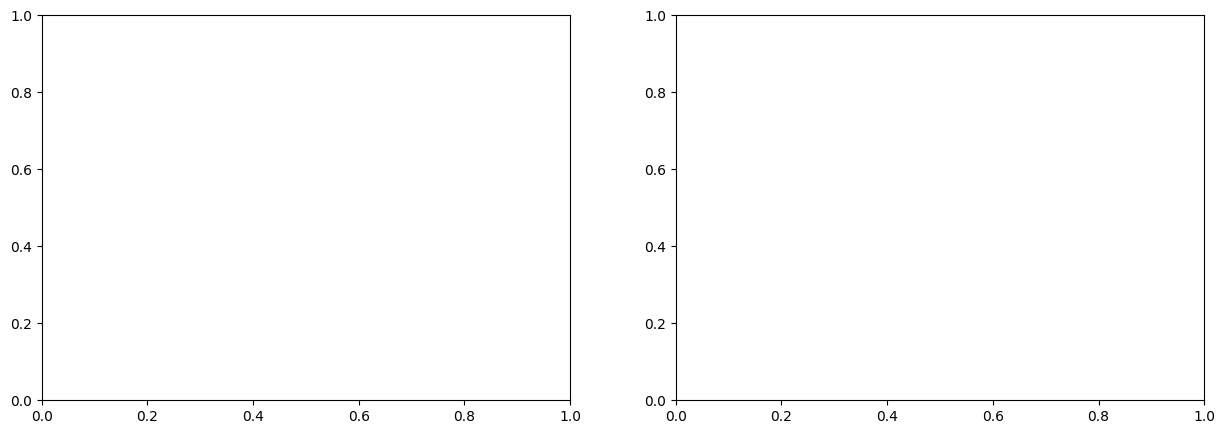

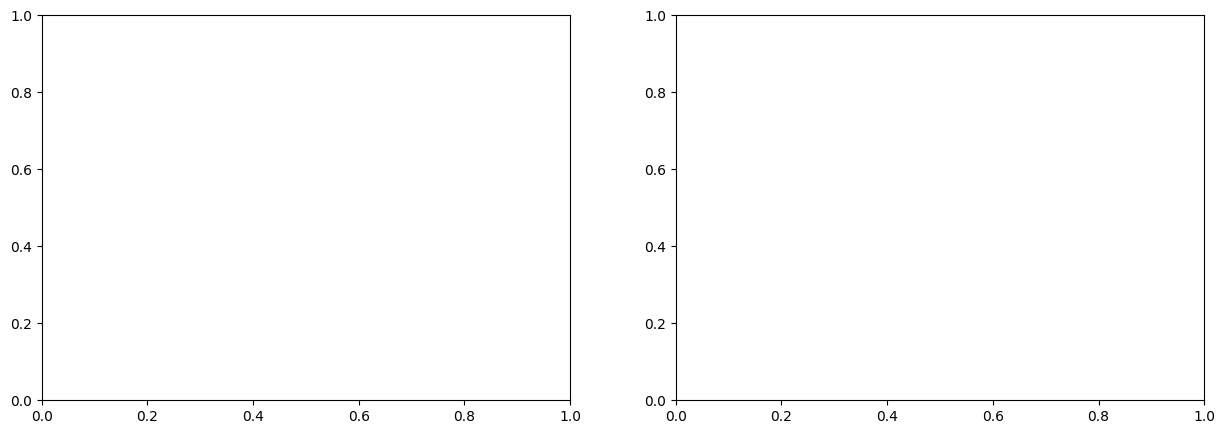

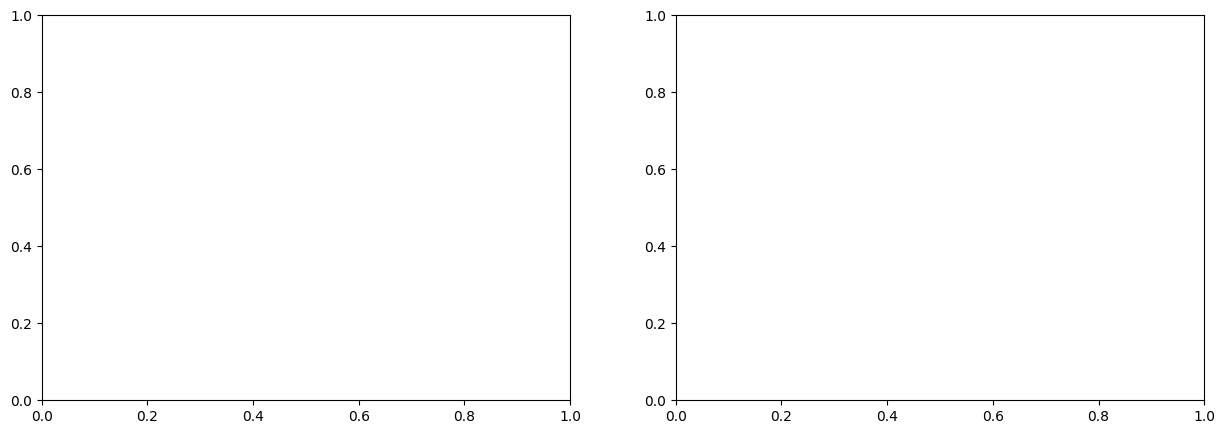

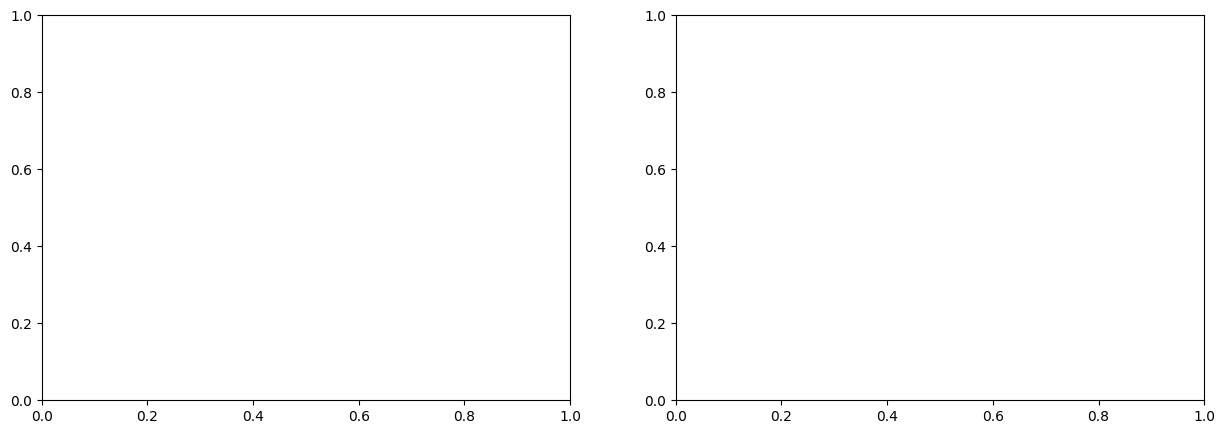

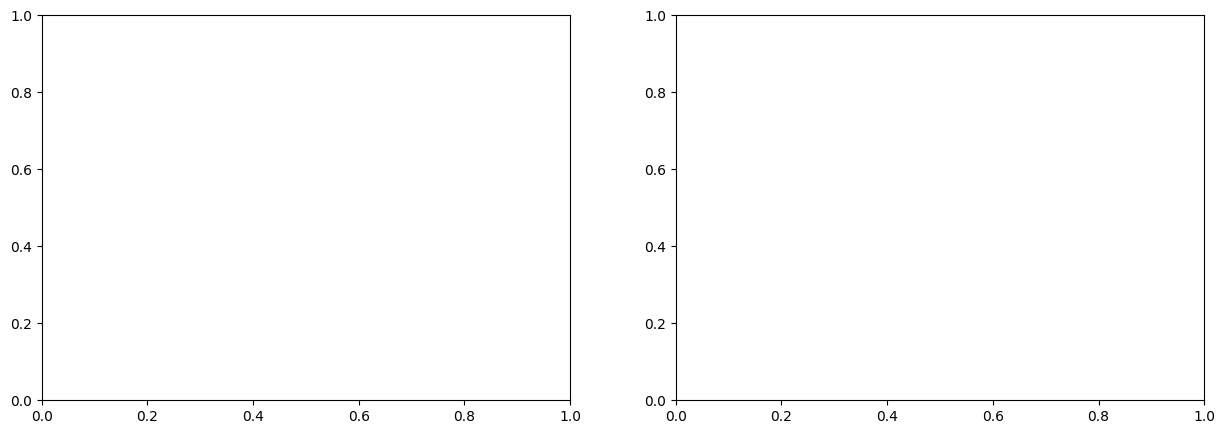

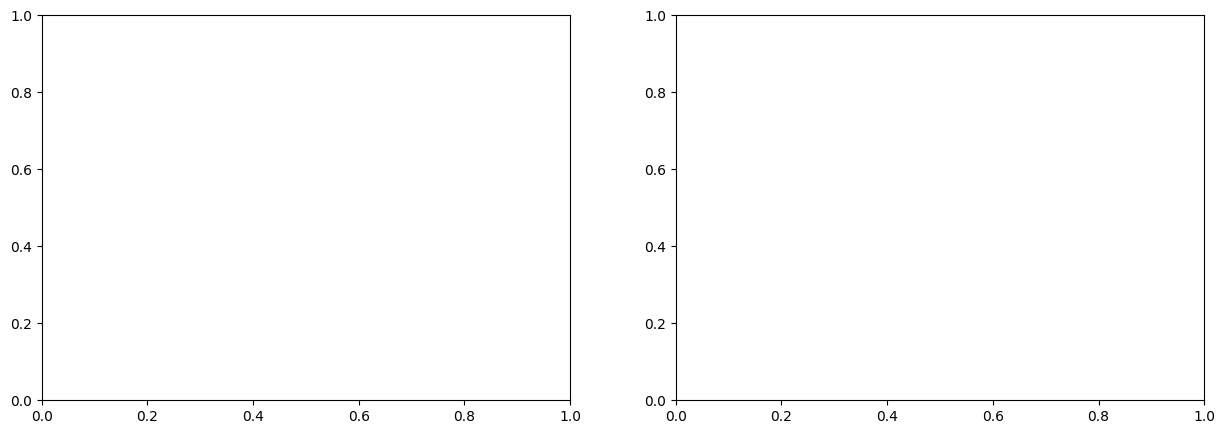

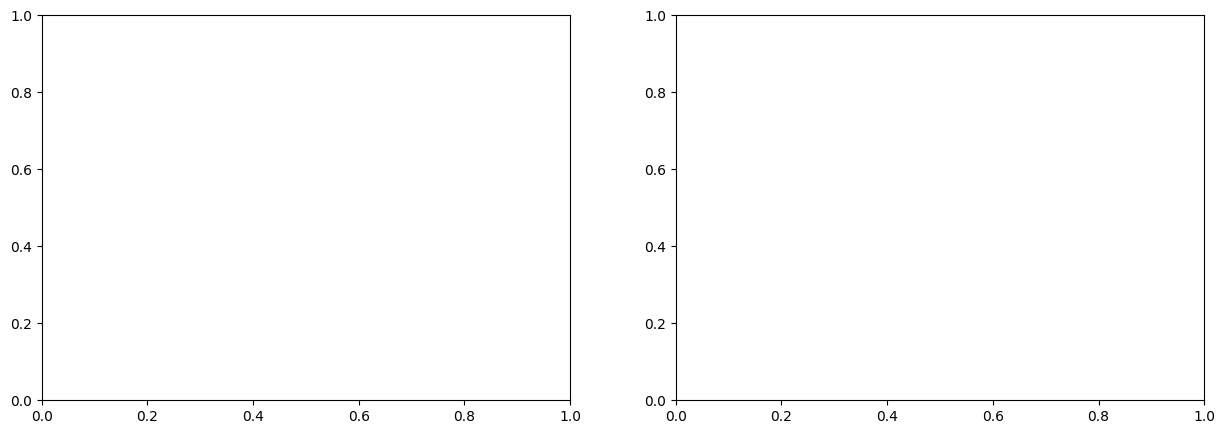

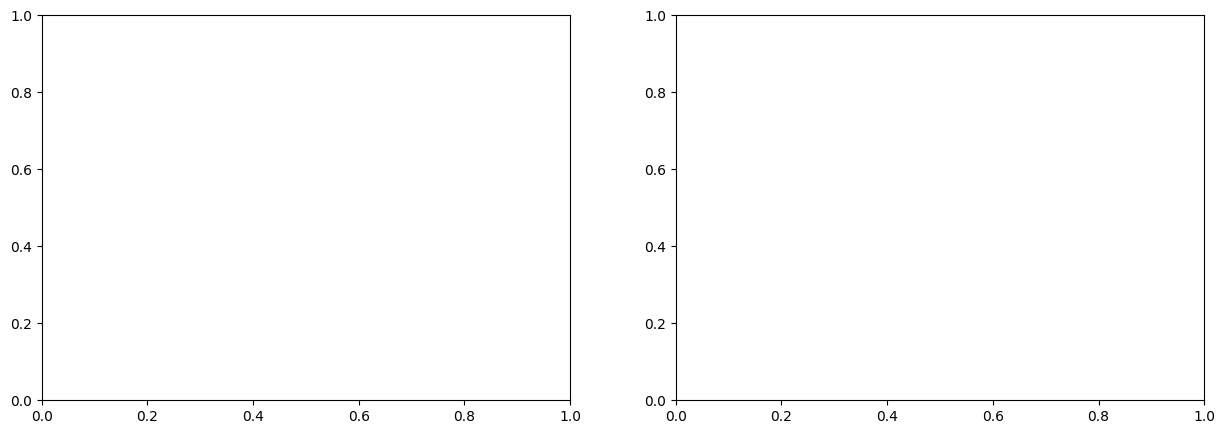

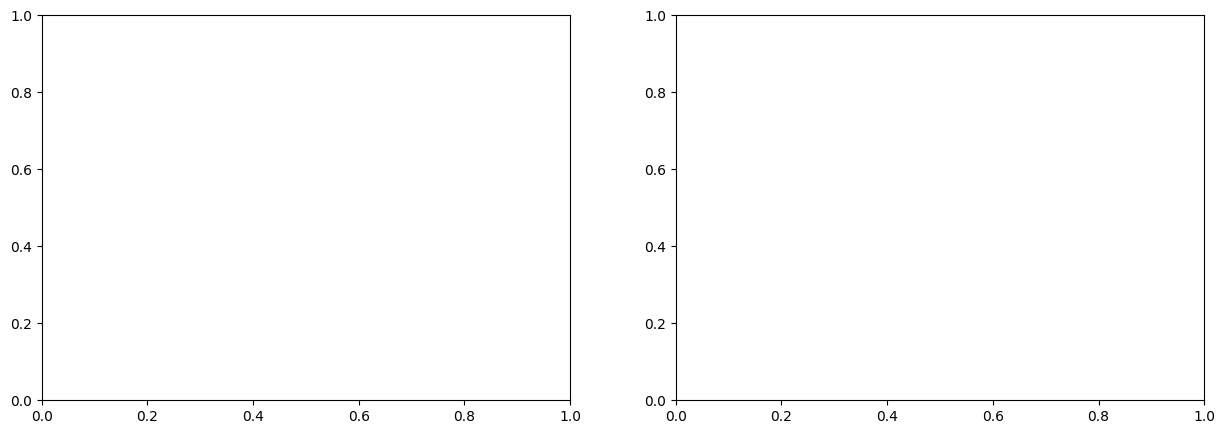

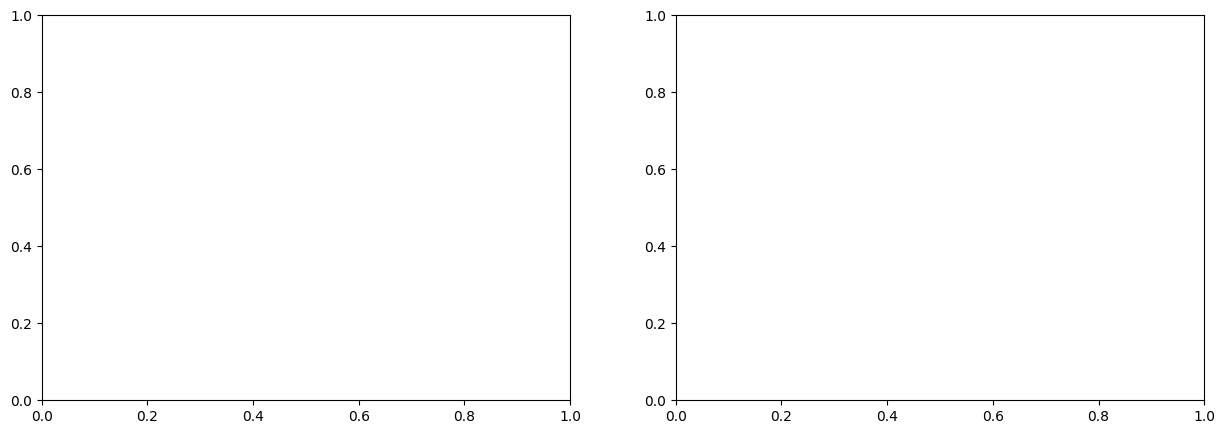

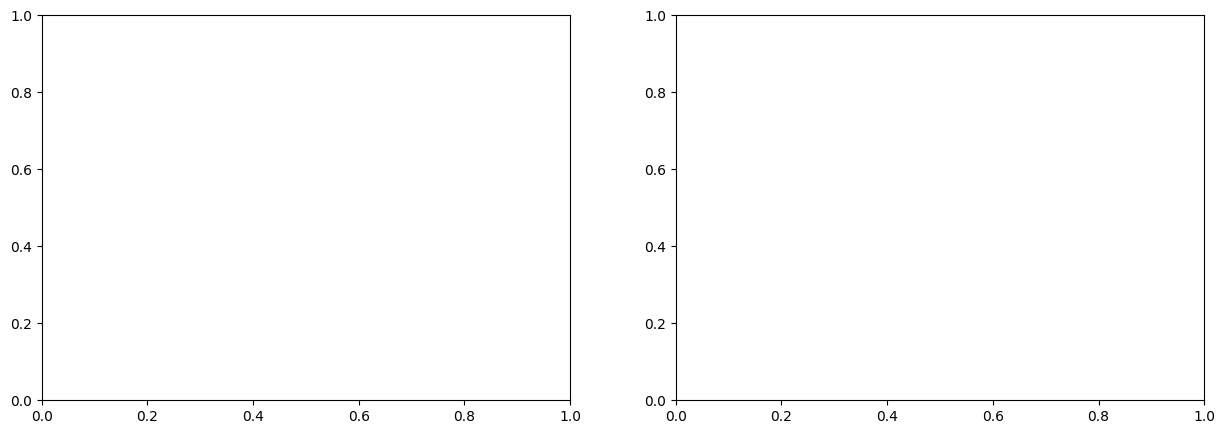

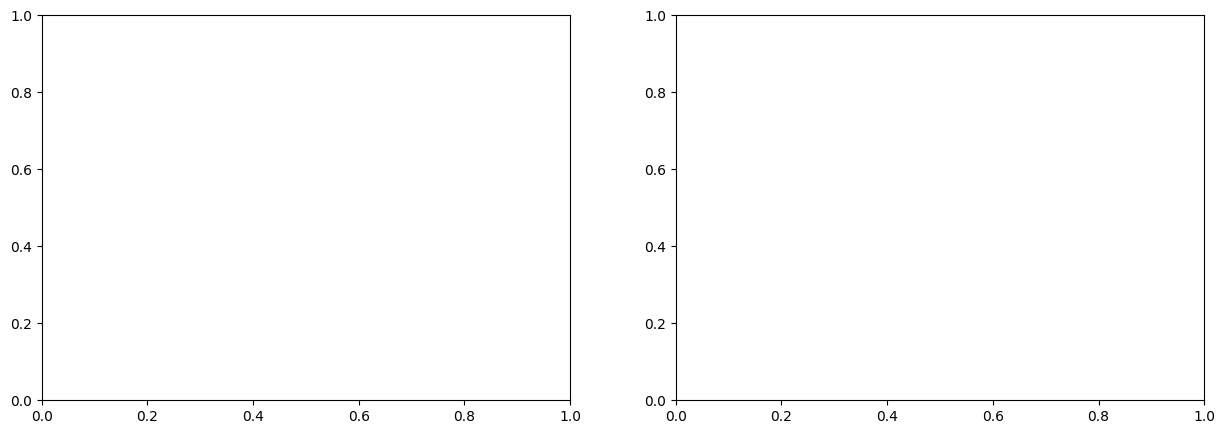

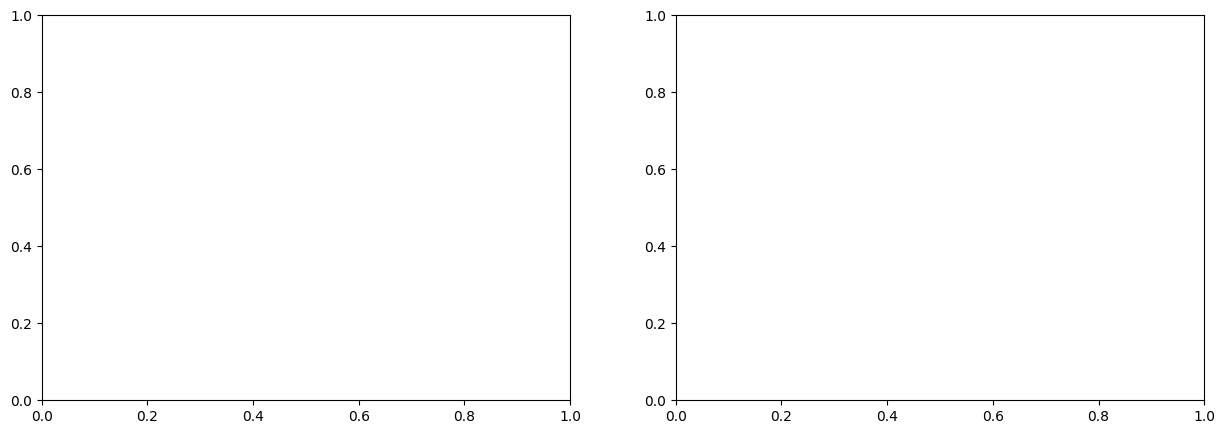

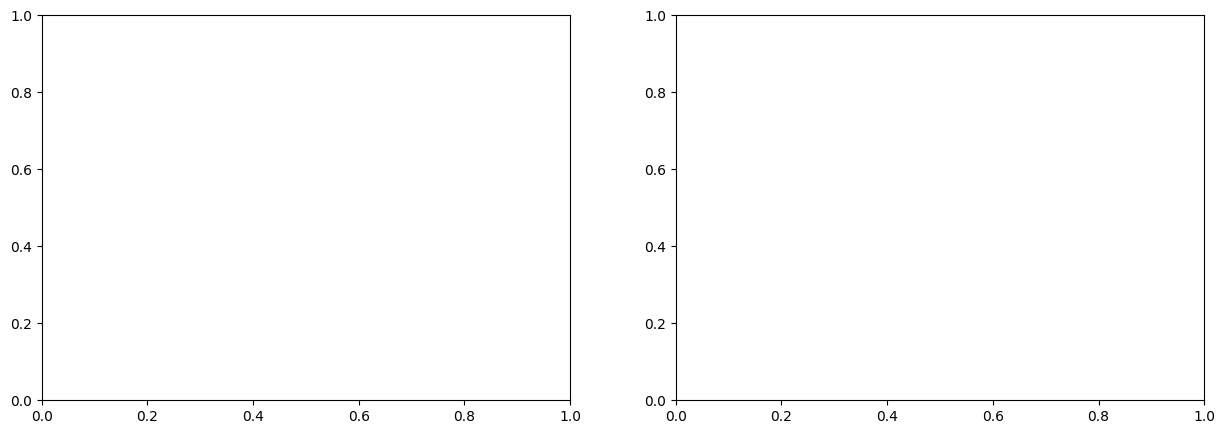

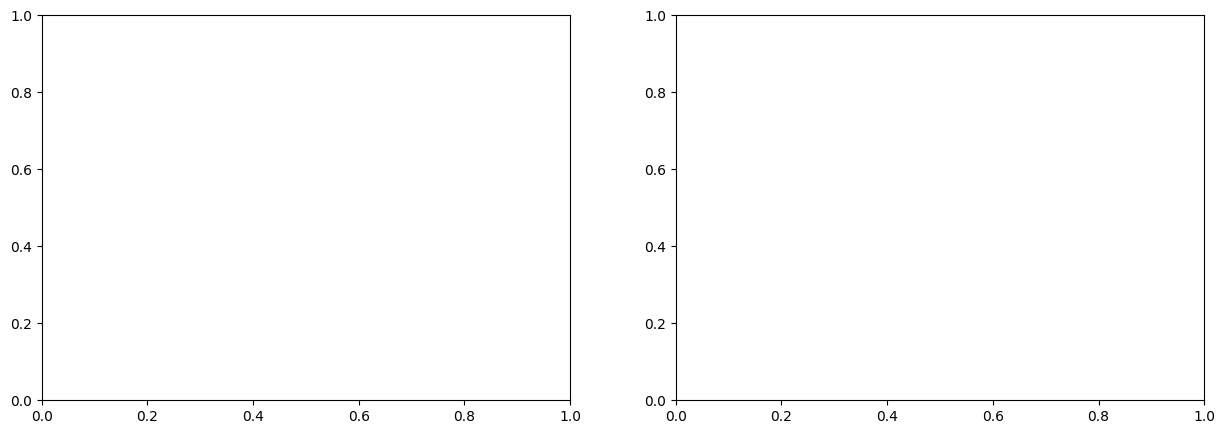

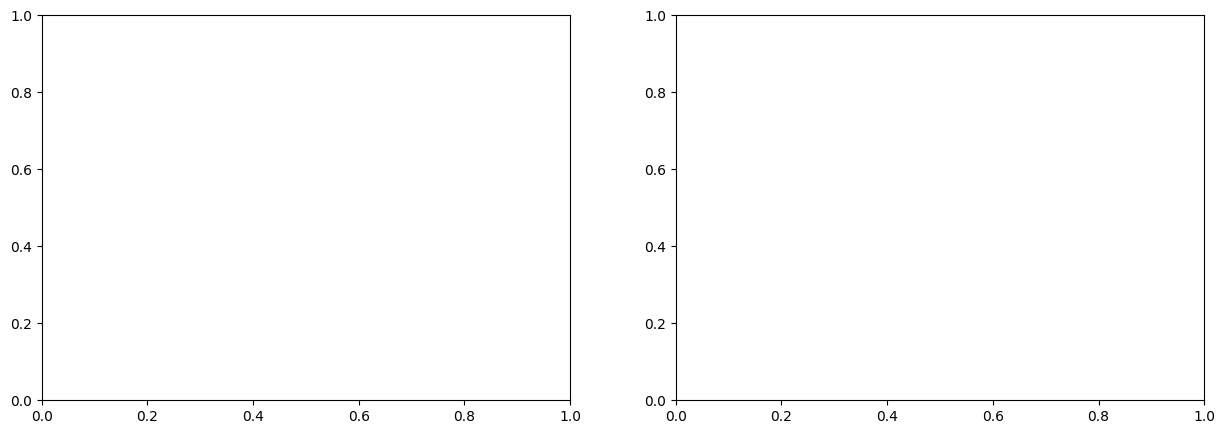

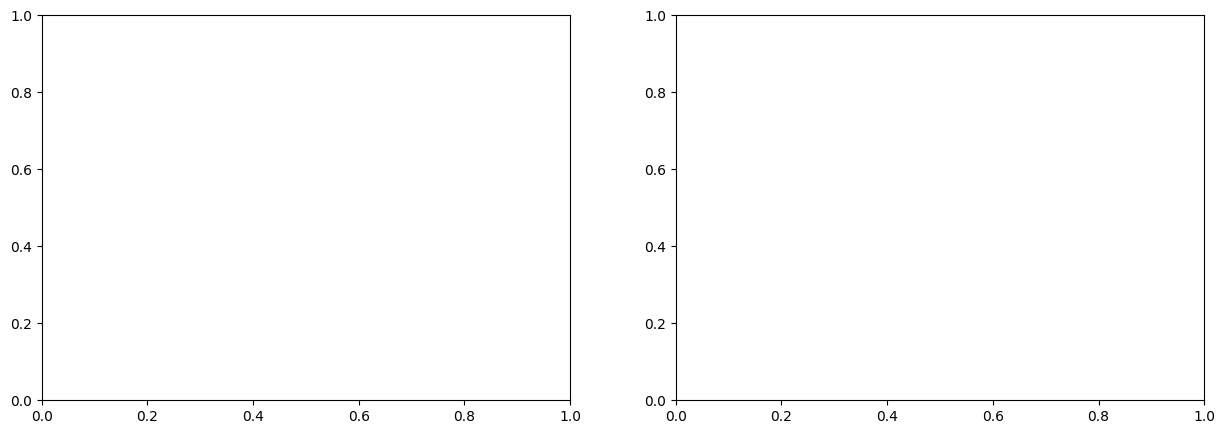

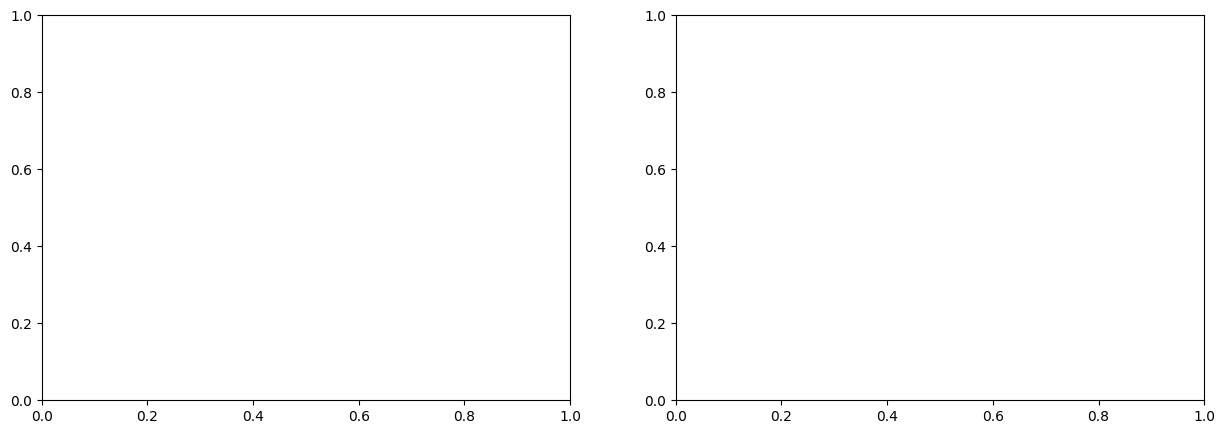

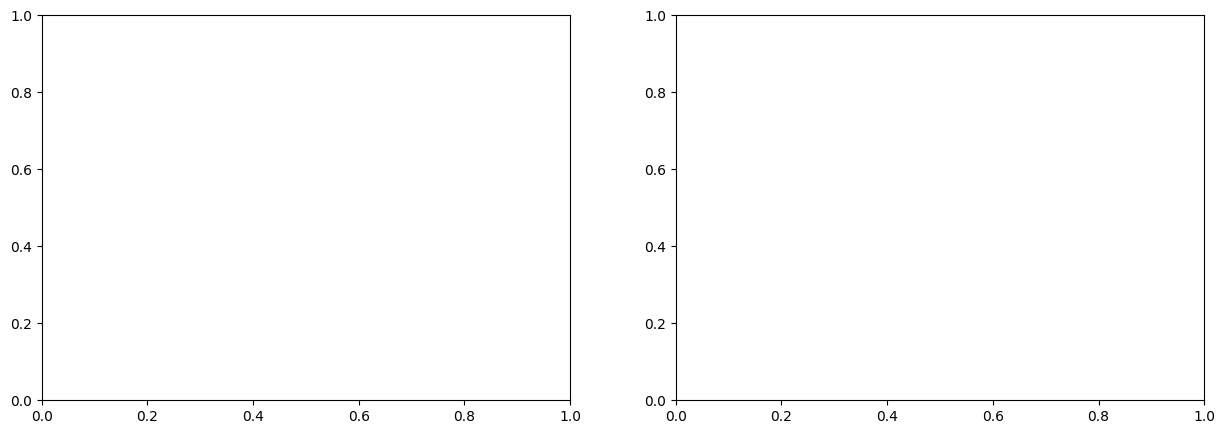

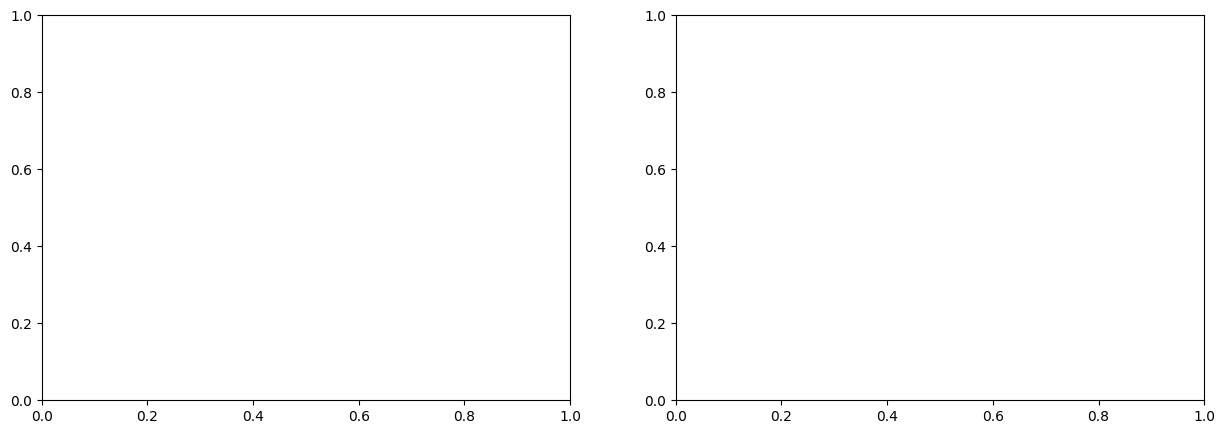

In [59]:
from torch.utils.data import Subset

small_ds = Subset(train_ds, range(100))
model = SimpleNet()

wandb.init(
    project="fer",
    group="cnnmlp",
    name="overfitting_small_ds"
)
model = train_loop(small_ds, small_ds, "cnnmlp", 0.0001, 8, model)
torch.save(model, "overfitter.pt")
wandb.finish()
